In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE
import joblib

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports successful")


✓ Imports successful


In [6]:
print("="*60)
print("LOADING PROCESSED DATA")
print("="*60)

# Load data
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

# Load metadata
metadata = joblib.load('../data/processed/metadata.pkl')
feature_names = metadata['feature_names']

print(f"✓ Training set: {X_train.shape}")
print(f"✓ Test set: {X_test.shape}")
print(f"✓ Features: {len(feature_names)}")

# Check class distribution
print("\nClass distribution:")
print(f"  Training:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"    {label}: {count:,} ({count/len(y_train)*100:.1f}%)")

print(f"  Test:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for label, count in zip(unique_test, counts_test):
    print(f"    {label}: {count:,} ({count/len(y_test)*100:.1f}%)")


LOADING PROCESSED DATA
✓ Training set: (831892, 41)
✓ Test set: (207974, 41)
✓ Features: 41

Class distribution:
  Training:
    0: 501,820 (60.3%)
    1: 330,072 (39.7%)
  Test:
    0: 125,455 (60.3%)
    1: 82,519 (39.7%)


In [7]:
print("\n" + "="*60)
print("HANDLING CLASS IMBALANCE WITH SMOTE")
print("="*60)

# Check current imbalance
imbalance_ratio = counts_train[0] / counts_train[1]
print(f"Current imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 1.5:
    print("\n⚠️  Significant class imbalance detected")
    print("Applying SMOTE to balance training data...")
    
    # Apply SMOTE
    smote = SMOTE(random_state=42, sampling_strategy='auto')
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    
    print(f"\n✓ SMOTE applied:")
    print(f"  Before: {X_train.shape[0]:,} samples")
    print(f"  After:  {X_train_balanced.shape[0]:,} samples")
    
    # Show new distribution
    unique_balanced, counts_balanced = np.unique(y_train_balanced, return_counts=True)
    print(f"\n  New distribution:")
    for label, count in zip(unique_balanced, counts_balanced):
        print(f"    {label}: {count:,} ({count/len(y_train_balanced)*100:.1f}%)")
    
    # Use balanced data for training
    X_train_final = X_train_balanced
    y_train_final = y_train_balanced
else:
    print("✓ Classes are reasonably balanced, no SMOTE needed")
    X_train_final = X_train
    y_train_final = y_train



HANDLING CLASS IMBALANCE WITH SMOTE
Current imbalance ratio: 1.52:1

⚠️  Significant class imbalance detected
Applying SMOTE to balance training data...

✓ SMOTE applied:
  Before: 831,892 samples
  After:  1,003,640 samples

  New distribution:
    0: 501,820 (50.0%)
    1: 501,820 (50.0%)


In [8]:
print("\n" + "="*60)
print("TRAINING XGBOOST CLASSIFIER")
print("="*60)

# Define XGBoost model
model = xgb.XGBClassifier(
    n_estimators=200,          # Number of trees
    max_depth=7,               # Maximum tree depth
    learning_rate=0.1,         # Step size shrinkage
    subsample=0.8,             # Fraction of samples per tree
    colsample_bytree=0.8,      # Fraction of features per tree
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,                 # Use all CPU cores
    verbosity=1
)

print("Model configuration:")
print(f"  Estimators: {model.n_estimators}")
print(f"  Max depth: {model.max_depth}")
print(f"  Learning rate: {model.learning_rate}")

print("\n🔄 Training model...")
print("This may take 1-3 minutes...\n")

# Train with evaluation on test set
model.fit(
    X_train_final, 
    y_train_final,
    eval_set=[(X_test, y_test)],
    verbose=50  # Print progress every 50 iterations
)

print("\n✅ Training complete!")



TRAINING XGBOOST CLASSIFIER
Model configuration:
  Estimators: 200
  Max depth: 7
  Learning rate: 0.1

🔄 Training model...
This may take 1-3 minutes...

[0]	validation_0-logloss:0.60130
[50]	validation_0-logloss:0.00705
[100]	validation_0-logloss:0.00118
[150]	validation_0-logloss:0.00070
[199]	validation_0-logloss:0.00063

✅ Training complete!


In [9]:
print("\n" + "="*60)
print("MAKING PREDICTIONS")
print("="*60)

# Predictions on training set
y_train_pred = model.predict(X_train_final)
y_train_proba = model.predict_proba(X_train_final)[:, 1]

# Predictions on test set
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

print("✓ Predictions generated")


MAKING PREDICTIONS
✓ Predictions generated


In [10]:
print("\n" + "="*60)
print("MODEL PERFORMANCE EVALUATION")
print("="*60)

def evaluate_model(y_true, y_pred, y_proba, dataset_name="Dataset"):
    """Calculate and display all metrics"""
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    
    print(f"\n{dataset_name} Metrics:")
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f} (of predicted attacks, how many are real)")
    print(f"  Recall:    {recall:.4f} (of real attacks, how many we caught)")
    print(f"  F1-Score:  {f1:.4f} (harmonic mean of precision & recall)")
    print(f"  ROC-AUC:   {auc:.4f} (area under ROC curve)")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }

# Evaluate on both sets
train_metrics = evaluate_model(y_train_final, y_train_pred, y_train_proba, "Training Set")
test_metrics = evaluate_model(y_test, y_test_pred, y_test_proba, "Test Set")

# Check for overfitting
print("\n" + "="*60)
print("OVERFITTING CHECK")
print("="*60)
accuracy_diff = train_metrics['accuracy'] - test_metrics['accuracy']
print(f"Training accuracy: {train_metrics['accuracy']:.4f}")
print(f"Test accuracy:     {test_metrics['accuracy']:.4f}")
print(f"Difference:        {accuracy_diff:.4f}")

if accuracy_diff < 0.05:
    print("✓ No significant overfitting detected")
elif accuracy_diff < 0.10:
    print("⚠️  Slight overfitting (acceptable)")
else:
    print("⚠️  Significant overfitting detected")



MODEL PERFORMANCE EVALUATION

Training Set Metrics:
  Accuracy:  0.9999 (99.99%)
  Precision: 0.9998 (of predicted attacks, how many are real)
  Recall:    1.0000 (of real attacks, how many we caught)
  F1-Score:  0.9999 (harmonic mean of precision & recall)
  ROC-AUC:   1.0000 (area under ROC curve)

Test Set Metrics:
  Accuracy:  0.9998 (99.98%)
  Precision: 0.9996 (of predicted attacks, how many are real)
  Recall:    0.9999 (of real attacks, how many we caught)
  F1-Score:  0.9998 (harmonic mean of precision & recall)
  ROC-AUC:   1.0000 (area under ROC curve)

OVERFITTING CHECK
Training accuracy: 0.9999
Test accuracy:     0.9998
Difference:        0.0001
✓ No significant overfitting detected



CONFUSION MATRIX

Confusion Matrix (Test Set):
[[125425     30]
 [     7  82512]]

Breakdown:
  True Negatives (TN):  125,425 (correctly identified as BENIGN)
  False Positives (FP): 30 (BENIGN wrongly flagged as ATTACK)
  False Negatives (FN): 7 (ATTACK missed)
  True Positives (TP):  82,512 (correctly identified as ATTACK)

✓ Saved confusion matrix plot


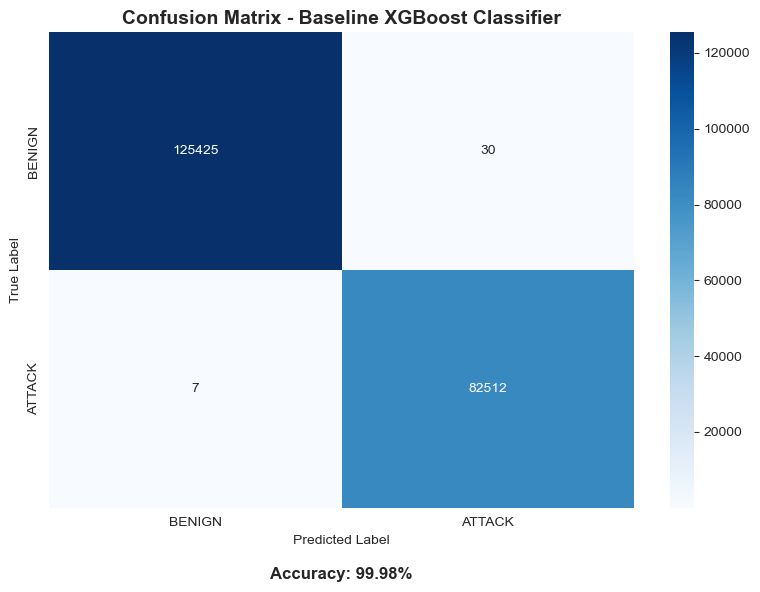

In [11]:
print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix (Test Set):")
print(cm)
print("\nBreakdown:")
print(f"  True Negatives (TN):  {cm[0,0]:,} (correctly identified as BENIGN)")
print(f"  False Positives (FP): {cm[0,1]:,} (BENIGN wrongly flagged as ATTACK)")
print(f"  False Negatives (FN): {cm[1,0]:,} (ATTACK missed)")
print(f"  True Positives (TP):  {cm[1,1]:,} (correctly identified as ATTACK)")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'])
plt.title('Confusion Matrix - Baseline XGBoost Classifier', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add accuracy to plot
accuracy_text = f'Accuracy: {test_metrics["accuracy"]:.2%}'
plt.text(0.5, -0.15, accuracy_text, ha='center', transform=plt.gca().transAxes, 
         fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/baseline_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved confusion matrix plot")
plt.show()

In [12]:
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)

print("\nTest Set Classification Report:")
print(classification_report(y_test, y_test_pred, 
                          target_names=['BENIGN', 'ATTACK'],
                          digits=4))


DETAILED CLASSIFICATION REPORT

Test Set Classification Report:
              precision    recall  f1-score   support

      BENIGN     0.9999    0.9998    0.9999    125455
      ATTACK     0.9996    0.9999    0.9998     82519

    accuracy                         0.9998    207974
   macro avg     0.9998    0.9998    0.9998    207974
weighted avg     0.9998    0.9998    0.9998    207974




ROC CURVE
✓ Saved ROC curve plot


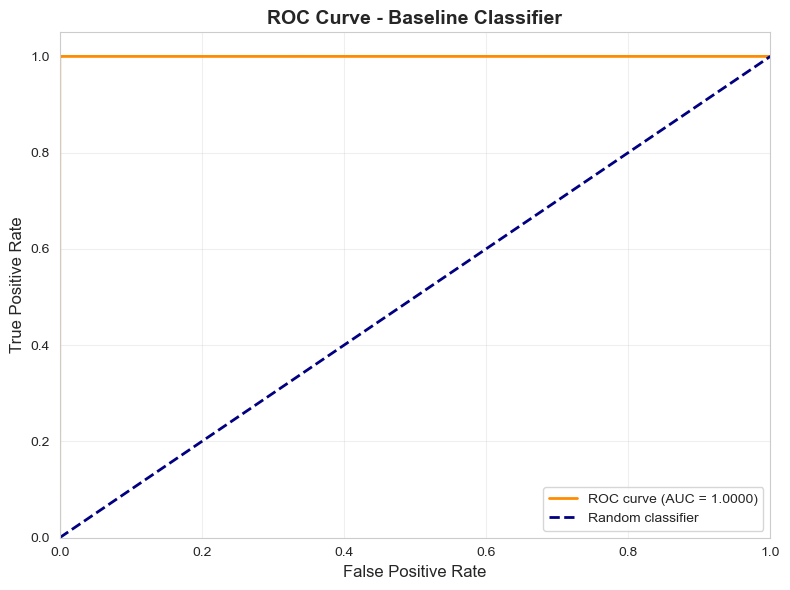


✓ ROC-AUC Score: 1.0000


In [13]:
print("\n" + "="*60)
print("ROC CURVE")
print("="*60)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Baseline Classifier', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/baseline_roc_curve.png', dpi=300, bbox_inches='tight')
print("✓ Saved ROC curve plot")
plt.show()

print(f"\n✓ ROC-AUC Score: {roc_auc:.4f}")



FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
                    feature  importance
      Bwd Packet Length Max    0.232197
     Fwd Packet Length Mean    0.187135
             URG Flag Count    0.157438
          Max Packet Length    0.131049
     Packet Length Variance    0.069961
           Destination Port    0.026735
          Total Fwd Packets    0.023891
             ACK Flag Count    0.021060
                 Active Std    0.018138
              Bwd Packets/s    0.013266
Total Length of Fwd Packets    0.012746
             PSH Flag Count    0.012297
       min_seg_size_forward    0.010239
                Bwd IAT Std    0.009960
                Fwd IAT Min    0.008953
    Init_Win_bytes_backward    0.008118
             FIN Flag Count    0.006157
               Flow IAT Std    0.005477
          Min Packet Length    0.004988
      Fwd Packet Length Max    0.004810

✓ Saved feature importance plot


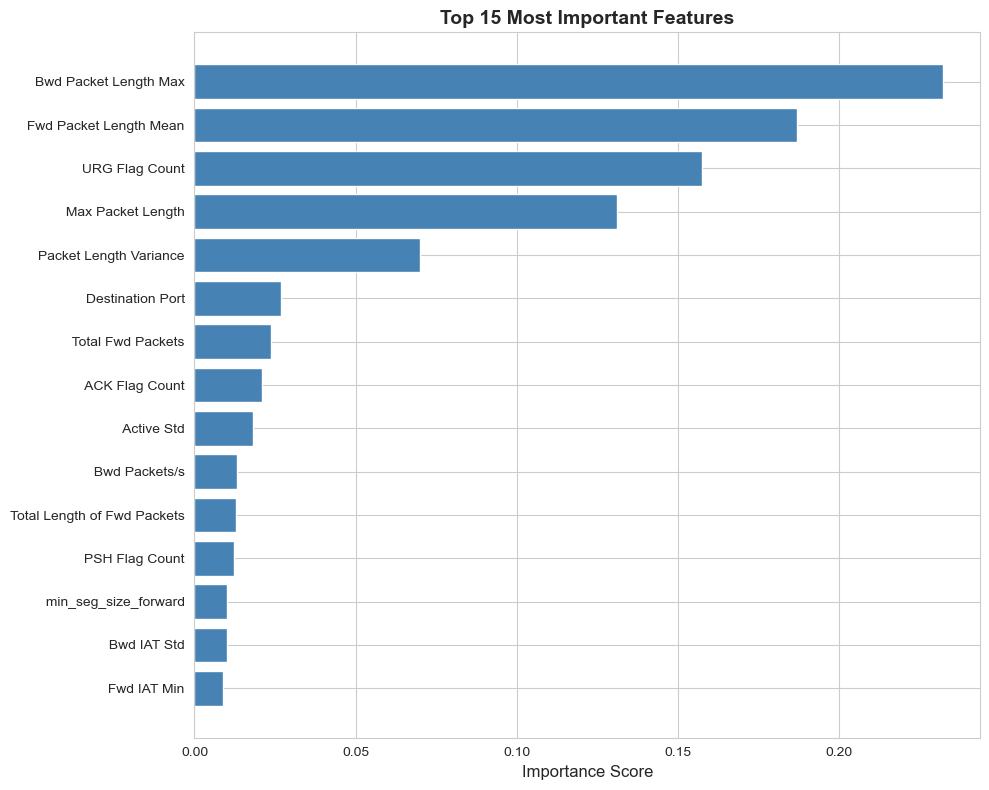

In [14]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importance
importance = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

# Top 20 features
print("\nTop 20 Most Important Features:")
print(feature_importance_df.head(20).to_string(index=False))

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'].values, color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../results/figures/baseline_feature_importance.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved feature importance plot")
plt.show()

In [15]:
print("\n" + "="*60)
print("SAVING MODEL")
print("="*60)

# Create models directory
Path('../models/base_classifier').mkdir(parents=True, exist_ok=True)

# Save model
model_path = '../models/base_classifier/xgboost_baseline.pkl'
joblib.dump(model, model_path)
print(f"✓ Model saved: {model_path}")

# Save metrics
metrics = {
    'train_metrics': train_metrics,
    'test_metrics': test_metrics,
    'confusion_matrix': cm.tolist(),
    'feature_importance': feature_importance_df.to_dict(),
}

metrics_path = '../models/base_classifier/baseline_metrics.pkl'
joblib.dump(metrics, metrics_path)
print(f"✓ Metrics saved: {metrics_path}")

# Save feature importance
feature_importance_df.to_csv('../models/base_classifier/feature_importance.csv', index=False)
print(f"✓ Feature importance saved as CSV")



SAVING MODEL
✓ Model saved: ../models/base_classifier/xgboost_baseline.pkl
✓ Metrics saved: ../models/base_classifier/baseline_metrics.pkl
✓ Feature importance saved as CSV


In [ ]:
print("\n" + "="*80)
print(" "*20 + "BASELINE MODEL SUMMARY")
print("="*80)

summary = f"""
Dataset:
  Training samples: {len(X_train_final):,} (after SMOTE)
  Test samples:     {len(X_test):,}
  Features:         {len(feature_names)}

Model: XGBoost Classifier
  Estimators:   {model.n_estimators}
  Max depth:    {model.max_depth}
  Learning rate: {model.learning_rate}

Performance (Test Set):
  Accuracy:  {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)
  Precision: {test_metrics['precision']:.4f}
  Recall:    {test_metrics['recall']:.4f}
  F1-Score:  {test_metrics['f1']:.4f}
  ROC-AUC:   {test_metrics['auc']:.4f}

Confusion Matrix:
  True Negatives:  {cm[0,0]:,}
  False Positives: {cm[0,1]:,}
  False Negatives: {cm[1,0]:,}
  True Positives:  {cm[1,1]:,}

Files Saved:
  ✓ Model: models/base_classifier/xgboost_baseline.pkl
  ✓ Metrics: models/base_classifier/baseline_metrics.pkl
  ✓ Feature importance: models/base_classifier/feature_importance.csv
  ✓ Confusion matrix plot: results/figures/baseline_confusion_matrix.png
  ✓ ROC curve plot: results/figures/baseline_roc_curve.png
  ✓ Feature importance plot: results/figures/baseline_feature_importance.png
"""

print(summary)

print("="*80)
print("✅ BASELINE CLASSIFIER TRAINING COMPLETE!")
print("="*80)
print("\nNext Steps:")
print("Implement adversarial attacks")
print("\nBaseline accuracy - {:.2f}% ".format(test_metrics['accuracy']*100))



                    BASELINE MODEL SUMMARY

Dataset:
  Training samples: 1,003,640 (after SMOTE)
  Test samples:     207,974
  Features:         41

Model: XGBoost Classifier
  Estimators:   200
  Max depth:    7
  Learning rate: 0.1

Performance (Test Set):
  Accuracy:  0.9998 (99.98%)
  Precision: 0.9996
  Recall:    0.9999
  F1-Score:  0.9998
  ROC-AUC:   1.0000

Confusion Matrix:
  True Negatives:  125,425
  False Positives: 30
  False Negatives: 7
  True Positives:  82,512

Files Saved:
  ✓ Model: models/base_classifier/xgboost_baseline.pkl
  ✓ Metrics: models/base_classifier/baseline_metrics.pkl
  ✓ Feature importance: models/base_classifier/feature_importance.csv
  ✓ Confusion matrix plot: results/figures/baseline_confusion_matrix.png
  ✓ ROC curve plot: results/figures/baseline_roc_curve.png
  ✓ Feature importance plot: results/figures/baseline_feature_importance.png

✅ BASELINE CLASSIFIER TRAINING COMPLETE!

Next Steps:
  1. Review the performance metrics above
  2. Check the